# Microsoft Stock — Séries Temporais

## Resumo executivo

Este recorte do trabalho analisa o preço de abertura (`Open`) da Microsoft e compara quatro modelos para prever o próximo pregão. O protocolo usa validação walk-forward, MAE e as mesmas datas de teste em todos os modelos. As variáveis exógenas são o fechamento (`Close`) e o volume (`Volume`) da própria ação, sempre observados no pregão anterior para evitar vazamento de informação.

- **Target:** preço de abertura (`Open`) do próximo pregão, em dólares.
- **Horizonte:** um pregão à frente.
- **Período:** 01/04/2015 a 31/03/2021.
- **Frequência:** pregões da bolsa, com período operacional de cinco pregões.
- **Variáveis exógenas:** `Close_lag_1` e `Log_Volume_lag_1`.
- **Modelos:** SARIMAX, Holt-Winters, Random Forest e XGBoost.
- **Métrica principal:** MAE fora da amostra.
- **Resultado:** SARIMAX em 1º lugar (MAE 1,643 USD) e XGBoost em 2º (MAE 2,583 USD).

## Responsabilidade

**Gabriel Bento** é responsável pela análise desta base e pela especialização em XGBoost. A comparação consolidada entre as cinco bases pertence ao relatório coletivo do grupo.

## Fonte da base

Os dados foram obtidos em [Microsoft Stock Time Series Analysis, no Kaggle](https://www.kaggle.com/datasets/vijayvvenkitesh/microsoft-stock-time-series-analysis).


## Imports

In [1]:
import time
import warnings
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path.cwd()
DATA = ROOT / "dataset"
RESULTS = ROOT / "resultados"
RESULTS.mkdir(exist_ok=True)

TARGET = "Open"
RANDOM_STATE = 42
TEST_RATIO = 0.25


Matplotlib is building the font cache; this may take a moment.


## Leitura, documentação e qualidade dos dados

A série-alvo representa o preço de abertura diário da ação da Microsoft em dólares. A auditoria verifica cobertura temporal, duplicidades, ausências e o registro incorreto de volume em 09/12/2019. O valor original é preservado no arquivo-fonte e corrigido somente na cópia de trabalho. `Close` e `Volume` são as variáveis exógenas definidas para a modelagem.


In [2]:
msft = pd.read_csv(DATA / "Microsoft_Stock.csv")

msft["Date"] = pd.to_datetime(msft["Date"]).dt.normalize()
msft = msft.sort_values("Date").drop_duplicates("Date").reset_index(drop=True)

# Correção apenas na cópia de trabalho. O arquivo original permanece inalterado.
data_outlier = pd.Timestamp("2019-12-09")
volume_original = int(msft.loc[msft["Date"].eq(data_outlier), "Volume"].iloc[0])
msft.loc[msft["Date"].eq(data_outlier), "Volume"] = 16_687_400

base = msft.copy()

auditoria = pd.DataFrame(
    {
        "Verificação": [
            "Observações", "Data inicial", "Data final", "Datas duplicadas",
            "Valores ausentes finais", "Volume original em 09/12/2019", "Volume corrigido"
        ],
        "Resultado": [
            len(base), base["Date"].min().date(), base["Date"].max().date(),
            int(base["Date"].duplicated().sum()), int(base.isna().sum().sum()),
            volume_original, 16_687_400
        ],
    }
)

dicionario_variaveis = pd.DataFrame(
    [
        ["Open", "Preço de abertura da MSFT", "USD", "Alvo no pregão t"],
        ["Close", "Preço de fechamento da MSFT", "USD", "Exógena com defasagem de 1 pregão"],
        ["Volume", "Quantidade negociada da MSFT", "Ações", "Exógena com log e defasagem de 1 pregão"],
    ],
    columns=["Variável", "Significado", "Unidade", "Uso na previsão"],
)

display(base.head())
display(auditoria)
display(dicionario_variaveis)
display(Markdown(
    "A base final não contém ausências nem datas duplicadas. As diferenças entre datas consecutivas "
    "correspondem a fins de semana e feriados; a unidade temporal usada na modelagem é o pregão, não o dia civil."
))


,Date,Open,High,Low,Close,Volume
0,2015-04-01,40.60,40.76,40.31,40.72,36865322
1,2015-04-02,40.66,40.74,40.12,40.29,37487476
2,2015-04-06,40.34,41.78,40.18,41.55,39223692
3,2015-04-07,41.61,41.91,41.31,41.53,28809375
4,2015-04-08,41.48,41.69,41.04,41.42,24753438


,Verificação,Resultado
0,Observações,1511
1,Data inicial,2015-04-01
2,Data final,2021-03-31
3,Datas duplicadas,0
4,Valores ausentes finais,0
5,Volume original em 09/12/2019,101612
6,Volume corrigido,16687400


,Variável,Significado,Unidade,Uso na previsão
0,Open,Preço de abertura da MSFT,USD,Alvo no pregão t
1,Close,Preço de fechamento da MSFT,USD,Exógena com defasagem de 1 pregão
2,Volume,Quantidade negociada da MSFT,Ações,Exógena com log e defasagem de 1 pregão


A base final não contém ausências nem datas duplicadas. As diferenças entre datas consecutivas correspondem a fins de semana e feriados; a unidade temporal usada na modelagem é o pregão, não o dia civil.

### Disponibilidade temporal e prevenção de vazamento

Para prever a abertura no pregão `t`, o notebook usa somente informações conhecidas até `t-1`. O fechamento e o volume do próprio pregão `t` ainda não existem no momento da abertura; por isso, `Close` e `Volume` entram defasados em um pregão. As médias e os desvios móveis também são calculados a partir da abertura anterior. Assim, valores observados no próprio dia previsto não entram nas features.


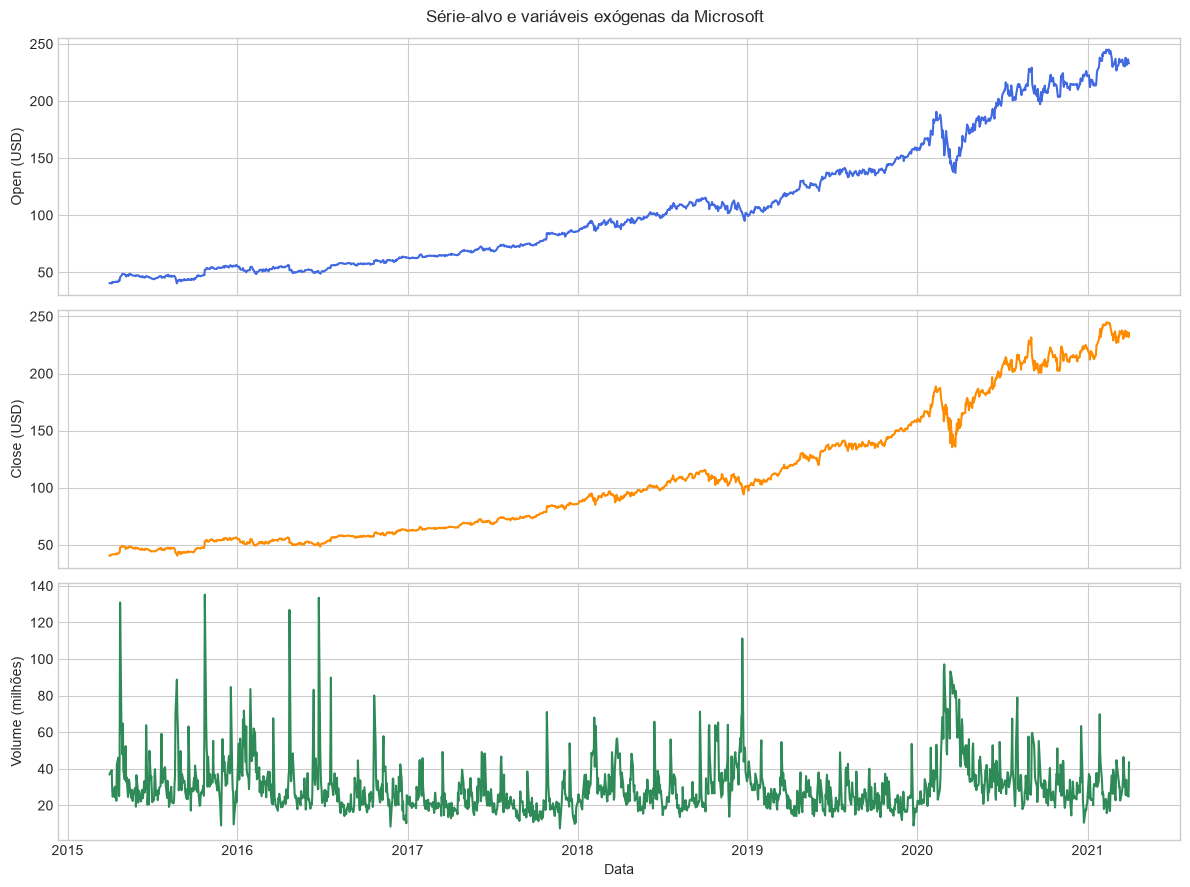

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(base["Date"], base["Open"], color="royalblue")
axes[0].set_ylabel("Open (USD)")
axes[1].plot(base["Date"], base["Close"], color="darkorange")
axes[1].set_ylabel("Close (USD)")
axes[2].plot(base["Date"], base["Volume"] / 1_000_000, color="seagreen")
axes[2].set_ylabel("Volume (milhões)")
axes[2].set_xlabel("Data")
fig.suptitle("Série-alvo e variáveis exógenas da Microsoft")
plt.tight_layout()
plt.show()


## Decomposição STL e características temporais

O período sazonal é definido como cinco pregões, correspondente a uma semana operacional típica. A decomposição separa tendência, sazonalidade e resíduo, e a força sazonal é calculada pelo método apresentado em aula.

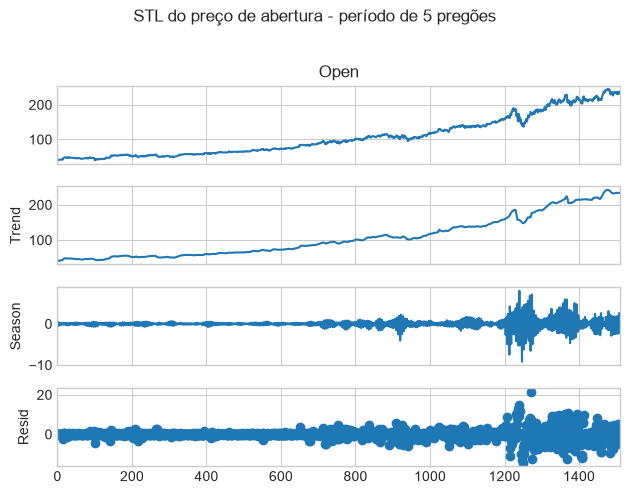

A tendência passa de aproximadamente **US$ 40.64** para **US$ 234.28**, indicando trajetória predominante de **alta** no período. A força sazonal semanal é **0.000**, portanto o ciclo de cinco pregões é fraco. O componente residual concentra choques de mercado e movimentos não explicados pela tendência.

In [4]:
stl = STL(base["Open"], period=5, robust=True).fit()
stl.plot()
plt.suptitle("STL do preço de abertura - período de 5 pregões", y=1.02)
plt.tight_layout()
plt.show()

variancia = np.nanvar(stl.seasonal + stl.resid)
forca_sazonalidade = max(0.0, 1 - np.nanvar(stl.resid) / variancia)

tendencia_inicio = float(stl.trend.dropna().iloc[0])
tendencia_fim = float(stl.trend.dropna().iloc[-1])
direcao = "alta" if tendencia_fim > tendencia_inicio else "queda"
display(Markdown(
    f"A tendência passa de aproximadamente **US$ {tendencia_inicio:.2f}** para **US$ {tendencia_fim:.2f}**, "
    f"indicando trajetória predominante de **{direcao}** no período. A força sazonal semanal é "
    f"**{forca_sazonalidade:.3f}**, portanto o ciclo de cinco pregões é fraco. O componente residual "
    "concentra choques de mercado e movimentos não explicados pela tendência."
))

## Feature Engineering

Foram criados lags da abertura, estatísticas móveis, fechamento e volume defasados e calendário com encoding cíclico. As primeiras 21 observações ficam incompletas por causa da maior janela móvel e são removidas antes da divisão temporal. Random Forest e XGBoost usam exatamente o mesmo conjunto de features. `Close` e `Volume` aparecem somente em `t-1`, evitando vazamento.


In [5]:
dados = base.set_index("Date").sort_index()
features = pd.DataFrame(index=dados.index)
features["Target_Open"] = dados["Open"]

for lag in [1, 2, 3, 5, 10]:
    features[f"Open_lag_{lag}"] = dados["Open"].shift(lag)

open_anterior = dados["Open"].shift(1)
for janela in [5, 21]:
    features[f"Open_media_{janela}"] = open_anterior.rolling(janela).mean()
    features[f"Open_desvio_{janela}"] = open_anterior.rolling(janela).std()

features["Close_lag_1"] = dados["Close"].shift(1)
features["Log_Volume_lag_1"] = np.log1p(dados["Volume"]).shift(1)

dia_semana = features.index.dayofweek
mes = features.index.month
features["Dia_semana_sen"] = np.sin(2 * np.pi * dia_semana / 5)
features["Dia_semana_cos"] = np.cos(2 * np.pi * dia_semana / 5)
features["Mes_sen"] = np.sin(2 * np.pi * (mes - 1) / 12)
features["Mes_cos"] = np.cos(2 * np.pi * (mes - 1) / 12)

linhas_antes = len(features)
features = features.replace([np.inf, -np.inf], np.nan).dropna().reset_index()
linhas_removidas = linhas_antes - len(features)
colunas_features = [c for c in features.columns if c not in ["Date", "Target_Open"]]

print(f"Linhas disponíveis para modelagem: {len(features)}")
print(f"Linhas iniciais removidas por lags e janelas: {linhas_removidas}")
display(pd.DataFrame({"Feature": colunas_features}))
display(features.head())


Linhas disponíveis para modelagem: 1490
Linhas iniciais removidas por lags e janelas: 21


,Feature
0,Open_lag_1
1,Open_lag_2
2,Open_lag_3
3,Open_lag_5
4,Open_lag_10
5,Open_media_5
6,Open_desvio_5
7,Open_media_21
8,Open_desvio_21
9,Close_lag_1


,Date,Target_Open,Open_lag_1,Open_lag_2,Open_lag_3,Open_lag_5,Open_lag_10,Open_media_5,Open_desvio_5,Open_media_21,Open_desvio_21,Close_lag_1,Log_Volume_lag_1,Dia_semana_sen,Dia_semana_cos,Mes_sen,Mes_cos
0,2015-05-01,48.58,48.70,48.72,47.78,45.66,41.67,47.618,1.264484,43.070952,2.743775,48.64,17.985665,-0.951057,0.309017,0.866025,-0.5
1,2015-05-04,48.37,48.58,48.70,48.72,47.23,41.73,48.202,0.667473,43.450952,2.930679,48.66,17.477464,0.000000,1.000000,0.866025,-0.5
2,2015-05-05,47.82,48.37,48.58,48.70,47.78,43.00,48.430,0.389102,43.818095,3.044294,48.24,17.343032,0.951057,0.309017,0.866025,-0.5
3,2015-05-06,47.57,47.82,48.37,48.58,48.72,42.67,48.438,0.372451,44.174286,3.054573,47.60,17.734890,0.587785,-0.809017,0.866025,-0.5
4,2015-05-07,46.27,47.57,47.82,48.37,48.70,42.85,48.208,0.490989,44.458095,3.081170,46.28,17.775047,-0.587785,-0.809017,0.866025,-0.5


## Separação temporal e protocolo walk-forward

Os 25% finais formam o teste e nunca participam da otimização. Dentro do treinamento, a busca usa `TimeSeriesSplit`, mantendo a ordem temporal. No teste final, cada modelo prevê um pregão, recebe a observação real e avança para a próxima origem de previsão. Os hiperparâmetros permanecem fixos.

In [6]:
X = features[colunas_features]
y = features["Target_Open"]

h = int(len(features) * TEST_RATIO)
split = len(features) - h

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
datas_teste = features["Date"].iloc[split:].reset_index(drop=True)

print(f"Treino: {len(X_train)} observações")
print(f"Teste: {len(X_test)} observações")
print(f"Período de teste: {datas_teste.min().date()} a {datas_teste.max().date()}")


Treino: 1118 observações
Teste: 372 observações
Período de teste: 2019-10-09 a 2021-03-31


## Otimização de Random Forest e XGBoost

A busca em grade usa quatro divisões temporais e MAE. Para Random Forest são testados número de árvores, profundidade, `min_samples_split`, `min_samples_leaf` e quantidade de features. Para XGBoost são testados número e profundidade das árvores, taxa de aprendizado, subamostragem de linhas e de colunas.

In [7]:
tscv = TimeSeriesSplit(n_splits=4)

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    {
        "n_estimators": [100, 200],
        "max_depth": [3, 6],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 5],
        "max_features": ["sqrt"],
    },
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=1,
)

xgb_search = GridSearchCV(
    XGBRegressor(
        objective="reg:squarederror",
        eval_metric="mae",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
    ),
    {
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.03, 0.10],
        "subsample": [0.8],
        "colsample_bytree": [0.8],
    },
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=1,
)

rf_search.fit(X_train, y_train)
xgb_search.fit(X_train, y_train)

melhor_rf = rf_search.best_estimator_
melhor_xgb = xgb_search.best_estimator_

otimizacao_ml = pd.DataFrame(
    {
        "Modelo": ["Random Forest", "XGBoost"],
        "MAE_CV": [-rf_search.best_score_, -xgb_search.best_score_],
        "Melhores parâmetros": [rf_search.best_params_, xgb_search.best_params_],
    }
)
display(otimizacao_ml)
display(Markdown(
    f"Configuração escolhida para Random Forest: `{rf_search.best_params_}`.  "
    f"Configuração escolhida para XGBoost: `{xgb_search.best_params_}`. "
    "A seleção foi feita somente com o conjunto de treinamento."
))

,Modelo,MAE_CV,Melhores parâmetros
0,Random Forest,10.017962,"{'max_depth': 6, 'max_features': 'sqrt', 'min_..."
1,XGBoost,9.468957,"{'colsample_bytree': 0.8, 'learning_rate': 0.1..."


Configuração escolhida para Random Forest: `{'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}`.  Configuração escolhida para XGBoost: `{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}`. A seleção foi feita somente com o conjunto de treinamento.

## Otimização de SARIMAX e Holt-Winters

O SARIMAX compara ordens não sazonais e sazonais com período cinco, escolhendo o menor AIC e registrando o BIC. `Close_lag_1` e `Log_Volume_lag_1` são as variáveis exógenas e são padronizadas com parâmetros aprendidos apenas no treino. O Holt-Winters compara ausência ou presença de tendência, sazonalidade aditiva e tendência amortecida; os coeficientes de suavização são estimados internamente no treino.


In [8]:
sarimax_colunas = ["Close_lag_1", "Log_Volume_lag_1"]
scaler = StandardScaler()
exog = np.empty((len(features), len(sarimax_colunas)))
exog[:split] = scaler.fit_transform(features[sarimax_colunas].iloc[:split])
exog[split:] = scaler.transform(features[sarimax_colunas].iloc[split:])

grade_sarimax = []
for ordem, ordem_sazonal in product(
    [(1, 1, 0), (0, 1, 1), (1, 1, 1)],
    [(0, 0, 0, 5), (1, 0, 0, 5)],
):
    try:
        ajuste = SARIMAX(
            y_train,
            exog=exog[:split],
            order=ordem,
            seasonal_order=ordem_sazonal,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False, maxiter=150)
        grade_sarimax.append(
            {"order": ordem, "seasonal_order": ordem_sazonal, "AIC": ajuste.aic, "BIC": ajuste.bic}
        )
    except Exception:
        pass

grade_sarimax = pd.DataFrame(grade_sarimax).sort_values("AIC").reset_index(drop=True)
melhor_sarimax = grade_sarimax.iloc[0]

validacao_hw = max(60, int(len(y_train) * 0.20))
hw_treino = y_train.iloc[:-validacao_hw]
hw_validacao = y_train.iloc[-validacao_hw:]
configs_hw = [
    {"trend": None, "seasonal": None, "damped_trend": False},
    {"trend": "add", "seasonal": None, "damped_trend": True},
    {"trend": "add", "seasonal": "add", "damped_trend": True},
]

avaliacao_hw = []
for config in configs_hw:
    modelo = ExponentialSmoothing(
        hw_treino,
        trend=config["trend"],
        seasonal=config["seasonal"],
        seasonal_periods=5 if config["seasonal"] else None,
        damped_trend=config["damped_trend"],
        initialization_method="estimated",
    ).fit(optimized=True, use_brute=False)
    previsao = modelo.forecast(validacao_hw)
    avaliacao_hw.append({**config, "MAE": mean_absolute_error(hw_validacao, previsao)})

avaliacao_hw = pd.DataFrame(avaliacao_hw).sort_values("MAE").reset_index(drop=True)
melhor_hw = avaliacao_hw.iloc[0].to_dict()

display(grade_sarimax)
display(avaliacao_hw)

hiperparametros = pd.DataFrame(
    [
        ["SARIMAX", str(tuple(melhor_sarimax["order"])) + " / " + str(tuple(melhor_sarimax["seasonal_order"])), "Menor AIC"],
        ["Holt-Winters", str({k: melhor_hw[k] for k in ["trend", "seasonal", "damped_trend"]}), "Menor MAE na validação"],
        ["Random Forest", str(rf_search.best_params_), "Menor MAE no TimeSeriesSplit"],
        ["XGBoost", str(xgb_search.best_params_), "Menor MAE no TimeSeriesSplit"],
    ],
    columns=["Modelo", "Configuração final", "Critério"],
)
hiperparametros.to_csv(RESULTS / "hiperparametros_modelos.csv", index=False, encoding="utf-8-sig")
display(hiperparametros)

,order,seasonal_order,AIC,BIC
0,"(1, 1, 1)","(1, 0, 0, 5)",2467.120230,2497.198325
1,"(0, 1, 1)","(1, 0, 0, 5)",2467.778675,2492.848252
2,"(0, 1, 1)","(0, 0, 0, 5)",2470.786837,2490.853276
3,"(1, 1, 1)","(0, 0, 0, 5)",2471.747607,2496.830655
4,"(1, 1, 0)","(1, 0, 0, 5)",2728.706086,2753.771165
5,"(1, 1, 0)","(0, 0, 0, 5)",2737.658091,2757.728116


,trend,seasonal,damped_trend,MAE
0,add,NaN,True,17.919971
1,NaN,NaN,False,17.920960
2,add,add,True,17.923960


,Modelo,Configuração final,Critério
0,SARIMAX,"(1, 1, 1) / (1, 0, 0, 5)",Menor AIC
1,Holt-Winters,"{'trend': 'add', 'seasonal': nan, 'damped_tren...",Menor MAE na validação
2,Random Forest,"{'max_depth': 6, 'max_features': 'sqrt', 'min_...",Menor MAE no TimeSeriesSplit
3,XGBoost,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",Menor MAE no TimeSeriesSplit


## Validação walk-forward

Todos os modelos usam horizonte de um pregão e as mesmas 372 datas de teste. Random Forest, XGBoost e Holt-Winters são reajustados com janela expansiva. O SARIMAX incorpora cada nova observação ao estado do modelo sem reestimar os hiperparâmetros escolhidos.

In [9]:
def walk_forward_ml(modelo, X, y, inicio_teste):
    previsoes = []
    inicio = time.perf_counter()
    for posicao in range(inicio_teste, len(y)):
        ajuste = clone(modelo)
        ajuste.fit(X.iloc[:posicao], y.iloc[:posicao])
        previsoes.append(float(ajuste.predict(X.iloc[[posicao]])[0]))
    return np.array(previsoes), time.perf_counter() - inicio


previsoes_rf, tempo_rf = walk_forward_ml(melhor_rf, X, y, split)
previsoes_xgb, tempo_xgb = walk_forward_ml(melhor_xgb, X, y, split)

inicio = time.perf_counter()
ajuste_sarimax = SARIMAX(
    y.iloc[:split],
    exog=exog[:split],
    order=tuple(melhor_sarimax["order"]),
    seasonal_order=tuple(melhor_sarimax["seasonal_order"]),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=200)
ajuste_sarimax_inicial = ajuste_sarimax
previsoes_sarimax = []

for posicao in range(split, len(y)):
    previsao = ajuste_sarimax.get_forecast(1, exog=exog[posicao:posicao + 1]).predicted_mean.iloc[0]
    previsoes_sarimax.append(float(previsao))
    novo_y = pd.Series([y.iloc[posicao]], index=[y.index[posicao]], name=y.name)
    ajuste_sarimax = ajuste_sarimax.append(novo_y, exog=exog[posicao:posicao + 1], refit=False)

tempo_sarimax = time.perf_counter() - inicio

inicio = time.perf_counter()
previsoes_hw = []
for posicao in range(split, len(y)):
    historico = y.iloc[:posicao]
    ajuste = ExponentialSmoothing(
        historico,
        trend=melhor_hw["trend"] if pd.notna(melhor_hw["trend"]) else None,
        seasonal=melhor_hw["seasonal"] if pd.notna(melhor_hw["seasonal"]) else None,
        seasonal_periods=5 if pd.notna(melhor_hw["seasonal"]) else None,
        damped_trend=bool(melhor_hw["damped_trend"]),
        initialization_method="estimated",
    ).fit(optimized=True, use_brute=False)
    previsoes_hw.append(float(ajuste.forecast(1).iloc[0]))

tempo_hw = time.perf_counter() - inicio


## Resultados comparativos por MAE

O ranking é calculado exclusivamente com previsões fora da amostra. O erro médio complementa o MAE e indica a direção do viés: valores positivos significam que, em média, o modelo subestimou a abertura.

,Ranking,Modelo,MAE,Erro_medio,Tempo_seg
0,1,SARIMAX,1.643362,-0.178496,24.494493
1,2,XGBoost,2.582876,0.778262,259.032481
2,3,Holt-Winters,2.781773,0.295228,15.325150
3,4,Random Forest,3.392368,1.287928,149.047377


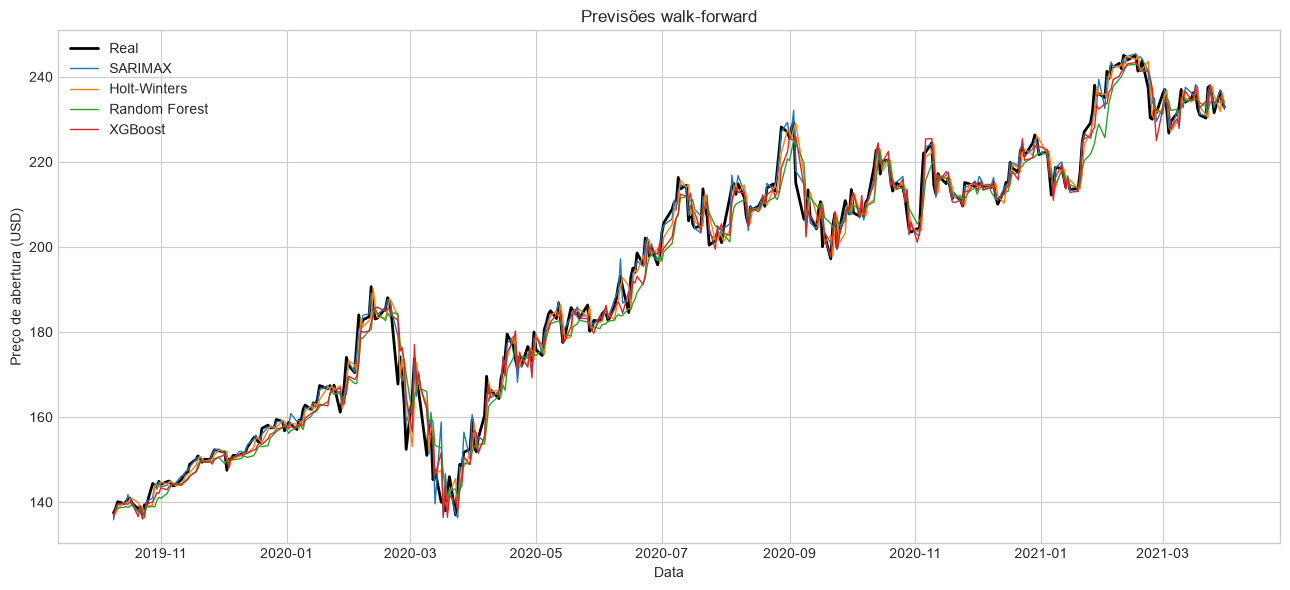

O melhor resultado desta base é do **SARIMAX**, com MAE de **1.643 USD**. O **XGBoost** ocupa a posição **2**, com MAE de **2.583 USD**. As diferenças são avaliadas apenas dentro desta base, pois MAEs de escalas distintas não devem ser somados.

In [10]:
previsoes = pd.DataFrame(
    {
        "Date": datas_teste,
        "Real": y_test.to_numpy(),
        "SARIMAX": previsoes_sarimax,
        "Holt-Winters": previsoes_hw,
        "Random Forest": previsoes_rf,
        "XGBoost": previsoes_xgb,
    }
)

tempos = {
    "SARIMAX": tempo_sarimax,
    "Holt-Winters": tempo_hw,
    "Random Forest": tempo_rf,
    "XGBoost": tempo_xgb,
}

metricas = []
for modelo in ["SARIMAX", "Holt-Winters", "Random Forest", "XGBoost"]:
    coluna_residuo = f"Residuo_{modelo.replace(' ', '_')}"
    previsoes[coluna_residuo] = previsoes["Real"] - previsoes[modelo]
    metricas.append(
        {
            "Modelo": modelo,
            "MAE": mean_absolute_error(previsoes["Real"], previsoes[modelo]),
            "Erro_medio": previsoes[coluna_residuo].mean(),
            "Tempo_seg": tempos[modelo],
        }
    )

metricas = pd.DataFrame(metricas).sort_values("MAE").reset_index(drop=True)
metricas.insert(0, "Ranking", np.arange(1, len(metricas) + 1))

display(metricas)

plt.figure(figsize=(13, 6))
plt.plot(previsoes["Date"], previsoes["Real"], color="black", linewidth=2, label="Real")
for modelo in ["SARIMAX", "Holt-Winters", "Random Forest", "XGBoost"]:
    plt.plot(previsoes["Date"], previsoes[modelo], linewidth=1, label=modelo)
plt.title("Previsões walk-forward")
plt.ylabel("Preço de abertura (USD)")
plt.xlabel("Data")
plt.legend()
plt.tight_layout()
plt.show()

melhor_linha = metricas.iloc[0]
xgb_linha = metricas.loc[metricas["Modelo"].eq("XGBoost")].iloc[0]
display(Markdown(
    f"O melhor resultado desta base é do **{melhor_linha['Modelo']}**, com MAE de "
    f"**{melhor_linha['MAE']:.3f} USD**. O **XGBoost** ocupa a posição "
    f"**{int(xgb_linha['Ranking'])}**, com MAE de **{xgb_linha['MAE']:.3f} USD**. "
    "As diferenças são avaliadas apenas dentro desta base, pois MAEs de escalas distintas não devem ser somados."
))

metricas.to_csv(RESULTS / "metricas_modelos.csv", index=False, encoding="utf-8-sig")
previsoes.to_csv(RESULTS / "previsoes_walk_forward.csv", index=False, encoding="utf-8-sig")

## Resíduos, ACF e Ljung-Box

Os resíduos são definidos como valor real menos previsão. Primeiro são observados ao longo do tempo; depois, a ACF e o teste de Ljung-Box em 20 defasagens verificam se ainda existe dependência temporal não capturada.

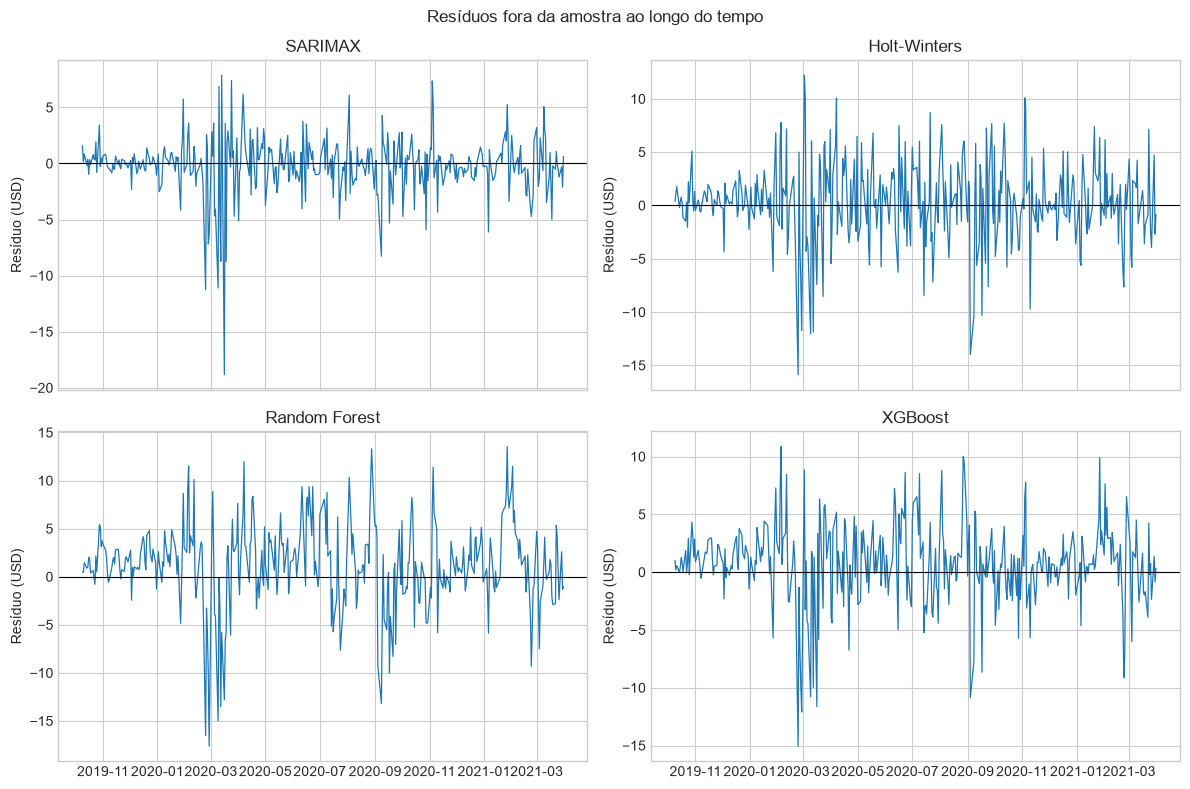

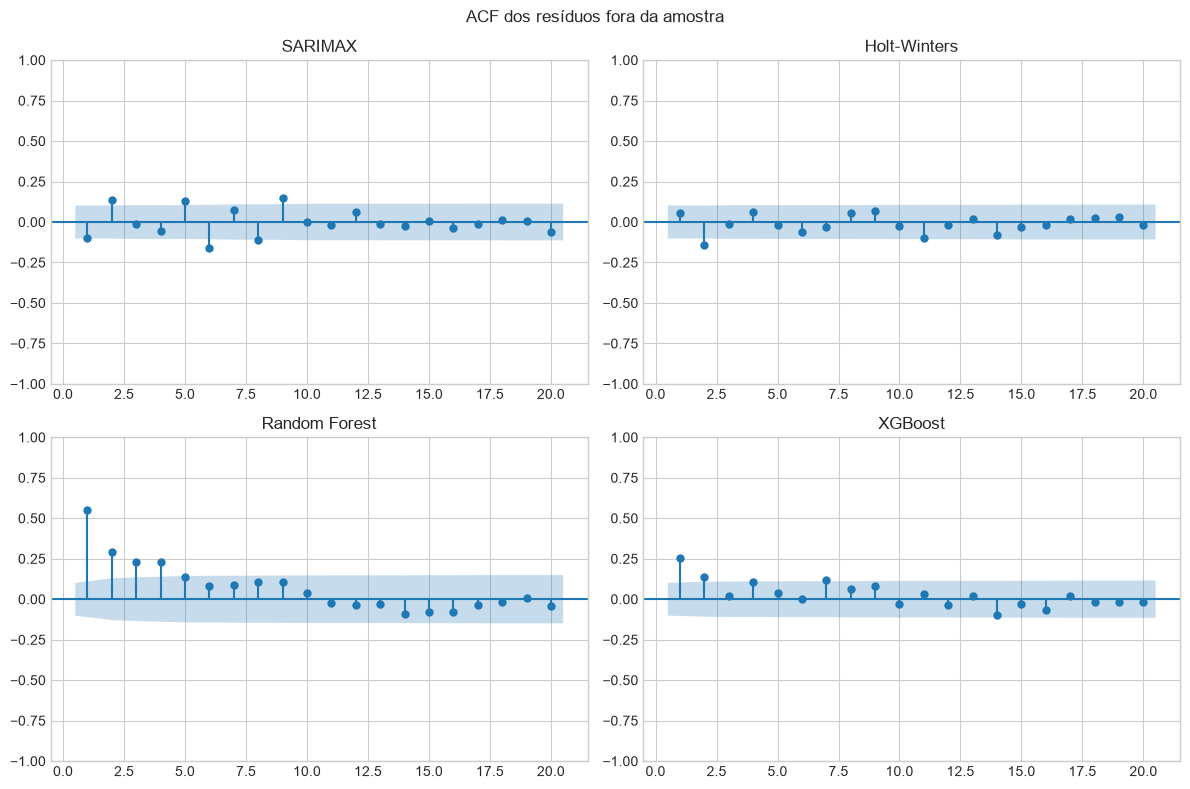

,Modelo,Ljung_Box,p_valor,Conclusao_5pct
0,SARIMAX,47.661354,4.744803e-04,Autocorrelação
1,Holt-Winters,23.309386,2.738596e-01,Sem evidência
2,Random Forest,217.360321,4.013766e-35,Autocorrelação
3,XGBoost,53.295403,7.352782e-05,Autocorrelação


Ao nível de 5%, há evidência de autocorrelação residual em **SARIMAX, Random Forest, XGBoost**. Não há evidência suficiente em **Holt-Winters**. A autocorrelação remanescente indica que ainda existem padrões temporais que esses modelos não capturaram completamente.

In [11]:
modelos = ["SARIMAX", "Holt-Winters", "Random Forest", "XGBoost"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for eixo, modelo in zip(axes.flat, modelos):
    residuos = previsoes["Real"] - previsoes[modelo]
    eixo.plot(previsoes["Date"], residuos, linewidth=0.9)
    eixo.axhline(0, color="black", linewidth=0.8)
    eixo.set_title(modelo)
    eixo.set_ylabel("Resíduo (USD)")
plt.suptitle("Resíduos fora da amostra ao longo do tempo")
plt.tight_layout()
plt.show()

resultados_ljung = []
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for eixo, modelo in zip(axes.flat, modelos):
    residuos = previsoes["Real"] - previsoes[modelo]
    teste = acorr_ljungbox(residuos, lags=[20], return_df=True).iloc[0]
    resultados_ljung.append(
        {
            "Modelo": modelo,
            "Ljung_Box": teste["lb_stat"],
            "p_valor": teste["lb_pvalue"],
            "Conclusao_5pct": "Autocorrelação" if teste["lb_pvalue"] < 0.05 else "Sem evidência",
        }
    )
    plot_acf(residuos, lags=20, ax=eixo, zero=False)
    eixo.set_title(modelo)

plt.suptitle("ACF dos resíduos fora da amostra")
plt.tight_layout()
plt.show()

resultados_ljung = pd.DataFrame(resultados_ljung)
display(resultados_ljung)

com_autocorrelacao = resultados_ljung.loc[
    resultados_ljung["p_valor"] < 0.05, "Modelo"
].tolist()
sem_autocorrelacao = resultados_ljung.loc[
    resultados_ljung["p_valor"] >= 0.05, "Modelo"
].tolist()
display(Markdown(
    f"Ao nível de 5%, há evidência de autocorrelação residual em **{', '.join(com_autocorrelacao) or 'nenhum modelo'}**. "
    f"Não há evidência suficiente em **{', '.join(sem_autocorrelacao) or 'nenhum modelo'}**. "
    "A autocorrelação remanescente indica que ainda existem padrões temporais que esses modelos não capturaram completamente."
))

resultados_ljung.to_csv(RESULTS / "ljung_box.csv", index=False, encoding="utf-8-sig")

## Importância das features e interpretação

Random Forest e XGBoost usam a importância nativa das árvores. No SARIMAX, são apresentados coeficientes, sinais e p-valores de `Close_lag_1` e `Log_Volume_lag_1`. Holt-Winters é univariado e, por isso, não possui importância de features.


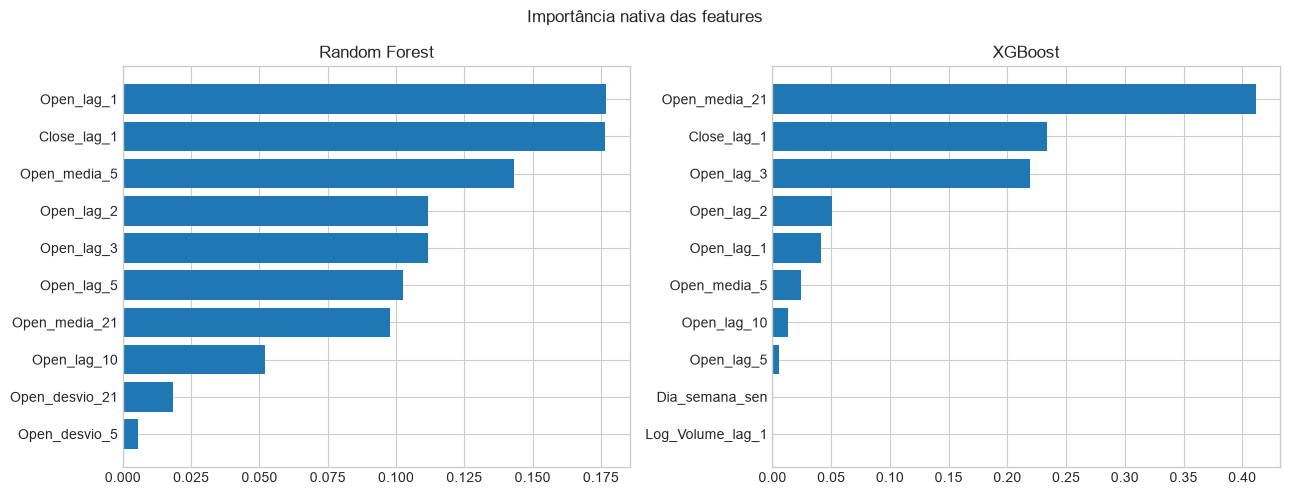

,Modelo,Feature,Importancia
0,Random Forest,Open_lag_1,0.176941
9,Random Forest,Close_lag_1,0.176495
5,Random Forest,Open_media_5,0.143353
1,Random Forest,Open_lag_2,0.111581
2,Random Forest,Open_lag_3,0.111567
22,XGBoost,Open_media_21,0.411581
24,XGBoost,Close_lag_1,0.233886
17,XGBoost,Open_lag_3,0.219565
16,XGBoost,Open_lag_2,0.050978
15,XGBoost,Open_lag_1,0.041224


,Variavel,Coeficiente,p_valor
0,Close_lag_1,28.599426,0.000000
1,Log_Volume_lag_1,0.047256,0.029485
2,ar.L1,-0.030185,0.210088
3,ma.L1,-1.000005,0.581194
4,ar.S.L5,0.012740,0.629557
5,sigma2,0.530553,0.581701


No XGBoost, as três features mais importantes são **Open_media_21**, **Close_lag_1**, **Open_lag_3**. Fechamento e volume defasados somam 23.4% da importância nativa; o histórico recente da abertura ainda explica a maior parte da previsão.

In [12]:
rf_final = clone(melhor_rf).fit(X_train, y_train)
xgb_final = clone(melhor_xgb).fit(X_train, y_train)

importancia = pd.concat(
    [
        pd.DataFrame(
            {"Modelo": "Random Forest", "Feature": colunas_features, "Importancia": rf_final.feature_importances_}
        ),
        pd.DataFrame(
            {"Modelo": "XGBoost", "Feature": colunas_features, "Importancia": xgb_final.feature_importances_}
        ),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for eixo, modelo in zip(axes, ["Random Forest", "XGBoost"]):
    top = importancia[importancia["Modelo"].eq(modelo)].nlargest(10, "Importancia").sort_values("Importancia")
    eixo.barh(top["Feature"], top["Importancia"])
    eixo.set_title(modelo)
plt.suptitle("Importância nativa das features")
plt.tight_layout()
plt.show()

coeficientes_sarimax = pd.DataFrame(
    {
        "Parametro": ajuste_sarimax_inicial.params.index,
        "Coeficiente": ajuste_sarimax_inicial.params.values,
        "p_valor": ajuste_sarimax_inicial.pvalues.values,
    }
)
mapa_exog = {f"x{i + 1}": nome for i, nome in enumerate(sarimax_colunas)}
coeficientes_sarimax["Variavel"] = coeficientes_sarimax["Parametro"].map(mapa_exog).fillna(
    coeficientes_sarimax["Parametro"]
)

top_importancia = importancia.sort_values(
    ["Modelo", "Importancia"], ascending=[True, False]
).groupby("Modelo").head(5)
display(top_importancia)
display(coeficientes_sarimax[["Variavel", "Coeficiente", "p_valor"]])

top_xgb = importancia.loc[importancia["Modelo"].eq("XGBoost")].nlargest(3, "Importancia")
externas_xgb = importancia.loc[
    importancia["Modelo"].eq("XGBoost")
    & importancia["Feature"].isin(["Close_lag_1", "Log_Volume_lag_1"]),
    "Importancia",
].sum()
display(Markdown(
    "No XGBoost, as três features mais importantes são **"
    + "**, **".join(top_xgb["Feature"].tolist())
    + f"**. Fechamento e volume defasados somam {externas_xgb:.1%} da importância nativa; "
    "o histórico recente da abertura ainda explica a maior parte da previsão."
))

importancia.to_csv(RESULTS / "importancia_features.csv", index=False, encoding="utf-8-sig")
coeficientes_sarimax.to_csv(RESULTS / "coeficientes_sarimax.csv", index=False, encoding="utf-8-sig")

## XGBoost - modelo de especialização

O XGBoost é um método de *gradient boosting*: árvores rasas são adicionadas em sequência e cada nova árvore busca reduzir os erros do conjunto anterior. A previsão final combina as contribuições de todas as árvores.

### Hipóteses e preparação

O algoritmo não pressupõe linearidade ou normalidade. Ele exige, porém, observações organizadas em tabela e uma separação temporal rigorosa. Por isso, a série é transformada em lags, janelas móveis e variáveis cíclicas. Não é necessária padronização para as árvores, e as linhas iniciais incompletas são removidas.

### Principais hiperparâmetros

- `n_estimators`: quantidade de árvores; mais árvores aumentam a capacidade e o custo.
- `max_depth`: profundidade de cada árvore; valores altos elevam o risco de sobreajuste.
- `learning_rate`: tamanho de cada correção; valores menores normalmente exigem mais árvores.
- `subsample`: fração das observações usada em cada árvore.
- `colsample_bytree`: fração das features disponível em cada árvore.

### Vantagens e limitações

O modelo captura relações não lineares e interações sem exigir uma forma funcional definida. Em contrapartida, depende de hiperparâmetros adequados, pode sobreajustar e não modela o tempo diretamente: toda a memória temporal precisa ser representada pelas features.

### Otimização e interpretação

A configuração é escolhida por busca em grade com `TimeSeriesSplit` e MAE, sem contato com o teste final. A interpretação utiliza importância nativa das árvores. Essa medida indica contribuição relativa para as divisões, mas não prova causalidade e pode favorecer variáveis correlacionadas.

## Conclusões, limitações e recomendações

O resultado desta base deve ser interpretado dentro do período analisado. O mercado muda de regime, o horizonte é de apenas um pregão e as variáveis exógenas entram como fechamento e volume observados no pregão anterior. Para uso futuro, recomenda-se reestimar os modelos periodicamente e monitorar MAE, viés e autocorrelação dos resíduos.

Não se calculam vitórias nem posição média entre bases neste notebook, pois isso exige os resultados das outras quatro bases. Essa comparação pertence ao relatório consolidado do grupo.

## Referências

- Kaggle. [Microsoft Stock Time Series Analysis](https://www.kaggle.com/datasets/vijayvvenkitesh/microsoft-stock-time-series-analysis).
- Statsmodels. Documentação de STL, SARIMAX, Exponential Smoothing e Ljung-Box.
- Scikit-learn. Documentação de Random Forest, GridSearchCV e TimeSeriesSplit.
- XGBoost. Documentação do XGBRegressor.
- Material da disciplina de Séries Temporais e enunciado do trabalho.

## Apêndice

O arquivo `registro_demandas.csv` registra as atividades de Gabriel Bento. Os CSVs em `resultados` preservam hiperparâmetros, previsões, resíduos, métricas, Ljung-Box, importâncias e coeficientes.


In [13]:
melhor = metricas.iloc[0]
xgb = metricas.loc[metricas["Modelo"].eq("XGBoost")].iloc[0]
display(Markdown(
    f"**Síntese final.** O **{melhor['Modelo']}** venceu nesta base com MAE de "
    f"**{melhor['MAE']:.3f} USD**. O **XGBoost** ficou em **{int(xgb['Ranking'])}º lugar**, "
    f"com MAE de **{xgb['MAE']:.3f} USD**. A força da sazonalidade semanal foi "
    f"**{forca_sazonalidade:.3f}**, indicando que o ciclo de cinco pregões tem pouca relevância diante "
    "da tendência e dos choques de mercado."
))

**Síntese final.** O **SARIMAX** venceu nesta base com MAE de **1.643 USD**. O **XGBoost** ficou em **2º lugar**, com MAE de **2.583 USD**. A força da sazonalidade semanal foi **0.000**, indicando que o ciclo de cinco pregões tem pouca relevância diante da tendência e dos choques de mercado.